In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

sys.path.append(r"C:\Users\siddh\Desktop\Graduate files\Research\mpemba_functions")
import mpemba
import fokker_planck
import importlib
importlib.reload(mpemba)
importlib.reload(fokker_planck)

<module 'fokker_planck' from 'C:\\Users\\siddh\\Desktop\\Graduate files\\Research\\mpemba_functions\\fokker_planck.py'>

In [3]:
D = 80
potential = mpemba.special_potentials.AsymmetricDoubleWellPotential(E_tilt=0.6, x_well=0.5, x_min=-5, x_max=5, force_asymmetry=0.3)


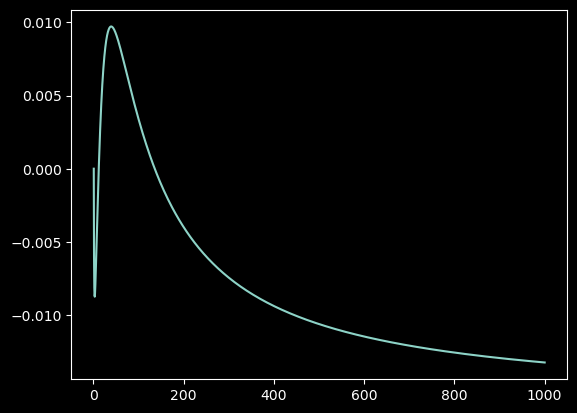

In [4]:
k_BTs = np.logspace(np.log10(1), np.log10(1000), 500)
a_2s = potential.a_k_boltzmannIC(k_BT=k_BTs, n_x=2000)
plt.plot(k_BTs, a_2s)

In [26]:
potential.infer_worst_temperature(40, k_BT_min=39, tolerance=3e-9) 

Local maximum exists!


array([39.64356794, 39.6537075 ])

100%|██████████| 9999/9999 [00:03<00:00, 2786.47it/s]


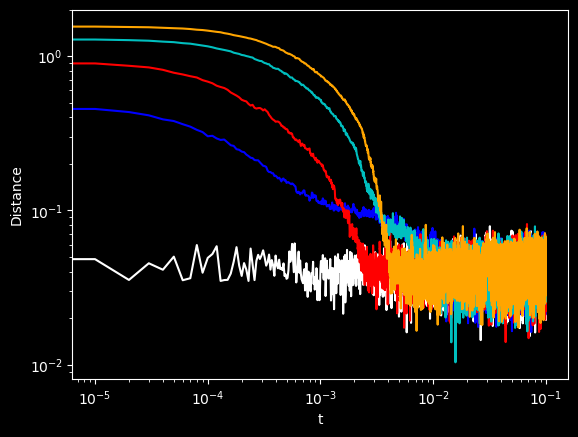

In [21]:
double_mpemba_ensemble = mpemba.construct_simulated_ensemble(potential, k_BTs=[137.14, 39.67, 12.05, 3, 1], num_particles=5000, gamma=1/D)
double_mpemba_ensemble.plot_distances(colors=['orange', 'c', 'r', 'b', 'w'])

In [ ]:
double_mpemba_ensemble.export_distances('double_mpemba.csv')

In [6]:
df = pd.DataFrame(a_2s, columns=['a2'], index=k_BTs)
df.index.name='T'
df.to_csv("a2s.csv")

In [29]:
p_trajectories = fokker_planck.analytic_solution([137.14, 39.64, 12.05, 3.05], potential=potential, D=D, error_tolerance=4e-3, n_x=1000, dt=1e-7)

 25%|██▌       | 1/4 [00:18<00:55, 18.48s/it]

0.08623720609247083 0.10274774276633035
0.08623720609247083 0.10274774276633035


 75%|███████▌  | 3/4 [00:55<00:18, 18.52s/it]

0.08623720609247083 0.10274774276633035
0.08623720609247083 0.10274774276633035


100%|██████████| 4/4 [01:14<00:00, 18.52s/it]


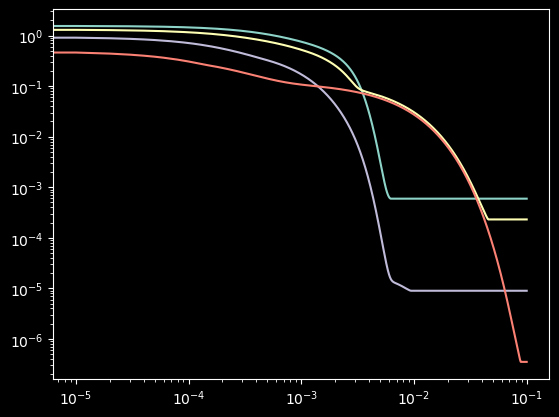

In [ ]:
FPE_distances = fokker_planck.analytical_distances_to_boltzmann(p_trajectories, potential)
plt.loglog(np.arange(p_trajectories.shape[2])*1e-5, FPE_distances.T)


In [33]:
double_mpemba_FPE_df = pd.DataFrame(FPE_distances.T, columns=['H','W','h','w'], index=np.arange(p_trajectories.shape[2])*1e-5)
double_mpemba_FPE_df.index.name = 't'
double_mpemba_FPE_df.to_csv("double_mpemba_FPE.csv")

100%|██████████| 9999/9999 [00:03<00:00, 2720.21it/s]


(0.01, 2)

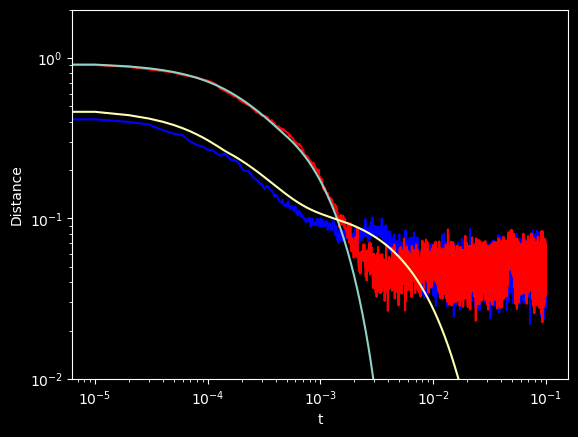

In [33]:
D = 80
ensemble = mpemba.construct_simulated_ensemble(potential, k_BTs=[12, 3, 1], num_particles=5_000, gamma=1/D)

ensemble.plot_distances()
plt.loglog(np.arange(p_trajectories.shape[2])*1e-5, FPE_distances.T)
plt.ylim((1e-2, 2))

In [34]:
df = pd.DataFrame(np.array([*FPE_distances, *(ensemble.get_distances())]).T, index=ensemble.times, columns=['FPEh', 'FPEw', 'langevinh', 'langevinw', 'langevinc'])
df.index.name='t'
# df.to_csv("potential_data.csv")

In [55]:
temperatures = [12.0,3.0,1.0]
data = mpemba.file_processing.load_processed_data([f"data_firstpassage_2_converted_T={temp}.csv" for temp in temperatures], temperatures)
ensemble = mpemba.Ensemble(data, potential)

100%|██████████| 3/3 [00:13<00:00,  4.42s/it]


In [56]:
ensemble.plot_distances(use_true_distro=False, colors=['r','b','w'])
bins, p_0s = ensemble.get_histograms()
interpolate_0 = scipy.interpolate.interp1d(bins, p_0s[0,:,0], kind='cubic')
interpolate_1 = scipy.interpolate.interp1d(bins, p_0s[1,:,0], kind='cubic')
x_fine = np.linspace(bins.min(), bins.max(), 1000)
dx = x_fine[1]-x_fine[0]
p_0 = fokker_planck.fokker_planck_solver(interpolate_0(x_fine)/(interpolate_0(x_fine).sum()*dx), potential, D=D, t_max=0.04, dt=1e-7, error_tolerance=5e-2, x=x_fine, saving_timestep=100)
p_1 = fokker_planck.fokker_planck_solver(interpolate_1(x_fine)/(interpolate_1(x_fine).sum()*dx), potential, D=D, t_max=0.04, dt=1e-7, error_tolerance=5e-2, x=x_fine, saving_timestep=100)
overlay_distances = fokker_planck.analytical_distances_to_boltzmann(np.array([p_0, p_1]), potential, axis=1, x=x_fine)
plt.loglog(np.arange(overlay_distances.shape[1])*1e-5, overlay_distances.T)
plt.ylim((1e-2,2))

C:\Users\siddh\Desktop\Graduate files\Research\mpemba_functions\mpemba.py:618: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(xlim)


(0.01, 2)

In [63]:
distances = ensemble.get_distances(use_true_distro=False)
FPE_distances = np.zeros_like(distances[1:])
FPE_distances[:,:4000] = overlay_distances
df = pd.DataFrame(np.array([*FPE_distances, *(ensemble.get_distances(use_true_distro=False))]).T, index=ensemble.times, columns=['FPEh', 'FPEw', 'h', 'w', 'c'])
df.index.name='t'
df.to_csv("real_data.csv")

In [30]:
print(mpemba.distance_functions.L1(p_0s[0,:,0], potential.boltzmann(bins, 1), dx=bins[0]-bins[1], axis=0))
print(mpemba.distance_functions.L1(p_0[:,0], potential.boltzmann(x_fine, 1), dx=dx, axis=0))

-1.0169932016137193
1.0188028017154758


100%|██████████| 3/3 [00:10<00:00,  3.58s/it]


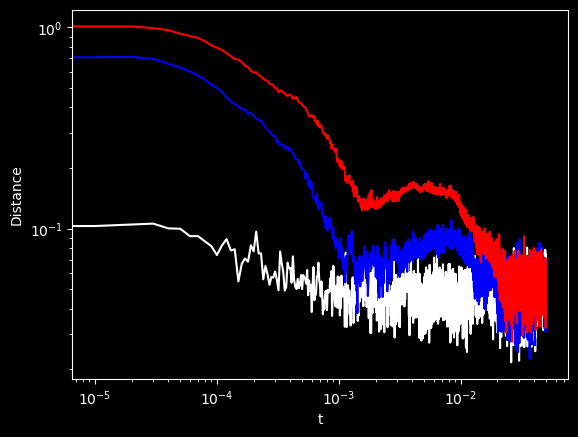

In [49]:
temperatures = [12.0,3.0,1.0]
data = mpemba.file_processing.load_processed_data([f"data_converted_T={temp}.csv" for temp in temperatures], temperatures)
ensemble = mpemba.Ensemble(data, potential)
ensemble.plot_distances(colors=['r','b','w'])

(0.01, 2)

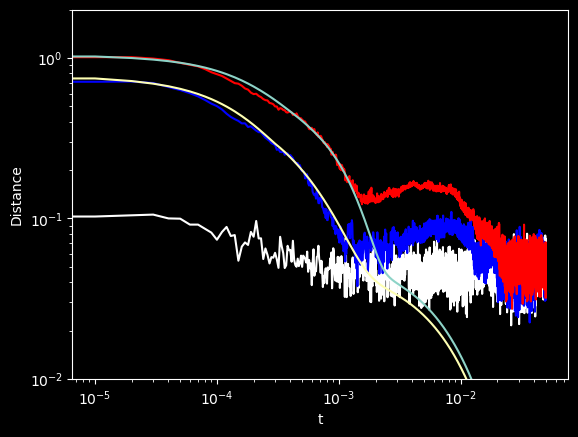

In [50]:
ensemble.plot_distances(use_true_distro=False, colors=['r','b','w'])
bins, p_0s = ensemble.get_histograms()
interpolate_0 = scipy.interpolate.interp1d(bins, p_0s[0,:,0], kind='cubic')
interpolate_1 = scipy.interpolate.interp1d(bins, p_0s[1,:,0], kind='cubic')
x_fine = np.linspace(bins.min(), bins.max(), 1000)
dx = x_fine[1]-x_fine[0]
p_0 = fokker_planck.fokker_planck_solver(interpolate_0(x_fine)/(interpolate_0(x_fine).sum()*dx), potential, D=D, t_max=0.04, dt=1e-7, error_tolerance=5e-2, x=x_fine, saving_timestep=100)
p_1 = fokker_planck.fokker_planck_solver(interpolate_1(x_fine)/(interpolate_1(x_fine).sum()*dx), potential, D=D, t_max=0.04, dt=1e-7, error_tolerance=5e-2, x=x_fine, saving_timestep=100)
overlay_distances = fokker_planck.analytical_distances_to_boltzmann(np.array([p_0, p_1]), potential, axis=1, x=x_fine)
plt.loglog(np.arange(overlay_distances.shape[1])*1e-5, overlay_distances.T)
plt.ylim((1e-2,2))

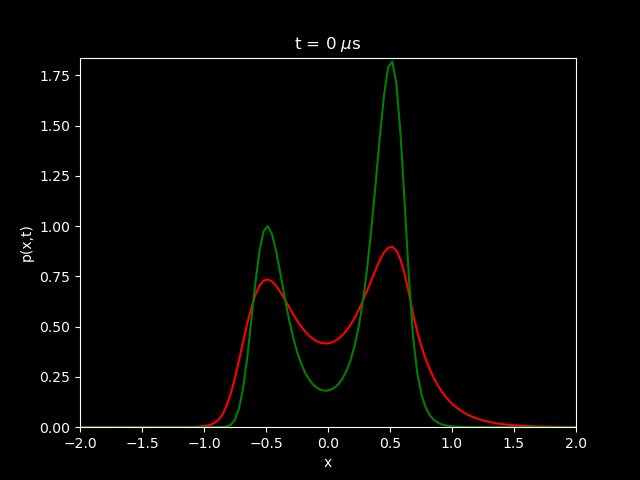

In [54]:
%matplotlib widget

ensemble.animate(T=3, max_left=-2, max_right=2)

In [52]:
%matplotlib inline